Accuracy: 1.0
Confusion Matrix:
 [[19  0]
 [ 0 26]]


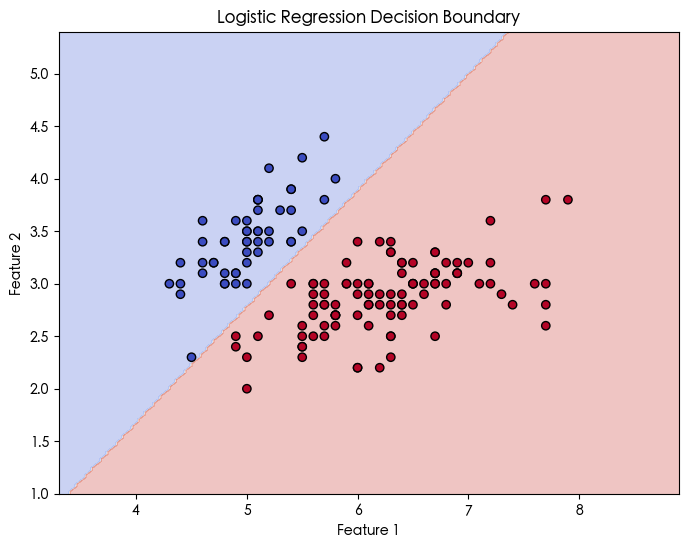

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 数据加载与预处理
iris = load_iris()
X = iris.data[:, :2]  # 仅使用前两个特征
y = (iris.target != 0).astype(int)  # 二分类问题

# 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 模型训练
model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

# 模型评估
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 可视化决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.show()

- `penalty='l2'` 表示使用 L2 正则化。
- `C=1.0` 表示正则化强度的倒数为 1.0，即正则化项的权重为 1.0。

在逻辑回归模型中，`penalty` 和 `C` 是两个重要的参数，它们与正则化有关。正则化是用于防止模型过拟合的一种技术。以下是这两个参数的详细解释：

### 1. `penalty`

`penalty` 参数指定了正则化的类型。它可以取以下值：

- `'l2'`：L2 正则化（默认值）。L2 正则化也称为岭回归（Ridge Regression），它通过在损失函数中添加一个惩罚项来限制权重的大小。L2 正则化的惩罚项是权重的平方和：
  $$
  \text{惩罚项} = \frac{1}{2} \sum_{j=1}^p w_j^2
  $$
  L2 正则化有助于防止过拟合，因为较大的权重会导致更大的惩罚，从而迫使模型选择较小的权重。

- `'l1'`：L1 正则化。L1 正则化也称为套索回归（Lasso Regression），它的惩罚项是权重的绝对值和：
  $$
  \text{惩罚项} = \sum_{j=1}^p |w_j|
  $$
  L1 正则化的一个重要特性是可以将一些权重稀疏化为零，从而进行特征选择。

### 2. `C`

`C` 参数是正则化强度的倒数。它控制了正则化项在整个损失函数中的权重。具体来说，损失函数可以表示为：

$$
J = \text{原始损失函数} + \frac{1}{C} \times \text{正则化项}
$$

- 当 `C` 较大时（例如，`C=1000`），正则化项的权重较小，模型更关注拟合训练数据，可能会导致过拟合。
- 当 `C` 较小时（例如，`C=0.01`），正则化项的权重较大，模型更关注权重的大小，可能会导致欠拟合。

`C` 的值通常通过交叉验证来选择，以找到最佳的正则化强度。

